# Notebook 01 — Exploratory Data Analysis

**Project:** India Gold Import Duty Hike — Pass-Through Study  
**Input:** `data/gold_policy_clean.csv` (output of `00_data_pipeline.ipynb`)  
**Rule:** Look, understand, document. No modelling here.

### Cell sequence
1. Load + basic inspection
2. Sub-period summary statistics
3. Premium time series — full sample, annotated
4. Policy window close-up (±30 trading days)
5. Pre/post distribution comparison
6. Confound check — Gold_USD and FX around the event
7. RBI forex reserves — macro backdrop
8. Seasonality overlay
9. Pre-treatment confound period (UAE disruption + bank IGST pause)
10. Stationarity tests + ACF/PACF
11. Correlation heatmap (regressors)
12. EDA findings summary → feeds hypothesis precommit

In [4]:
# ── Cell 1: Load clean dataset + basic inspection ─────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

# ── Constants ─────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data')
FIG_DIR     = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

POLICY_DATE = pd.Timestamp('2026-05-13')   # treatment date
DUTY_CUT    = pd.Timestamp('2024-07-24')   # Jul 2024 cut: 15% → 6%

# ── Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / 'gold_policy_clean.csv',
                 index_col='date', parse_dates=True)

# ── Shape and date range ──────────────────────────────────────────────────
print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns    : {list(df.columns)}')

# ── Null counts ───────────────────────────────────────────────────────────
print('\n--- Null counts per column ---')
nulls = df.isnull().sum()
for col, n in nulls.items():
    pct = n / len(df) * 100
    bar = '█' * int(pct / 5)
    print(f'  {col:<30} {n:>4} ({pct:>5.1f}%)  {bar}')

# ── Sub-period row counts ─────────────────────────────────────────────────
print('\n--- Observations per duty period ---')
high  = df[df.index <  DUTY_CUT]
low   = df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]
post  = df[df.index >= POLICY_DATE]
print(f'  High-duty  (Jan 2022 – Jul 23 2024): {len(high):>4} rows')
print(f'  Low-duty   (Jul 24 2024 – May 12 2026): {len(low):>4} rows')
print(f'  Post-hike  (May 13 2026+):           {len(post):>4} rows')

# ── Key columns: first and last 3 rows ────────────────────────────────────
key_cols = ['Gold_USD', 'rupees_per_dollar', 'Gold_INR_PM',
            'parity_pre', 'domestic_premium', 'post_hike']
print('\n--- First 3 rows (key columns) ---')
print(df[key_cols].head(3).to_string())
print('\n--- Last 3 rows (key columns) ---')
print(df[key_cols].tail(3).to_string())

Shape      : (1158, 25)
Date range : 2022-01-03 → 2026-06-12
Columns    : ['Oil_USD', 'Gold_USD', 'rupees_per_dollar', 'Kalyan', 'Silver_USD', 'Nifty50', 'US10Y_yield', 'GOLDBEES', 'Gold_INR_PM', 'Silver_INR_PM', 'ibja_source', 'forex_reserves_usd_bn', 'parity_actual', 'parity_pre', 'parity_post', 'domestic_premium', 'premium_pct', 'silver_parity_pre', 'silver_premium', 'post_hike', 'days_since_hike', 'delta_Gold_USD', 'delta_FX', 'delta_Oil', 'MCX_Gold_close']

--- Null counts per column ---
  Oil_USD                          40 (  3.5%)  
  Gold_USD                         45 (  3.9%)  
  rupees_per_dollar                 3 (  0.3%)  
  Kalyan                           60 (  5.2%)  █
  Silver_USD                       41 (  3.5%)  
  Nifty50                          63 (  5.4%)  █
  US10Y_yield                      43 (  3.7%)  
  GOLDBEES                         61 (  5.3%)  █
  Gold_INR_PM                     348 ( 30.1%)  ██████
  Silver_INR_PM                   348 ( 30.1%)  ████

In [5]:
# ── Cell 2: Sub-period summary statistics — Paper Table 1 ────────────────
# Breaks the sample into three duty regimes and reports key statistics.
# This is the first table in the paper: establishes baseline behavior
# across periods and motivates the ITS design.

import pandas as pd
import numpy as np

# ── Define sub-periods ────────────────────────────────────────────────────
periods = {
    'High-duty (Jan 2022–Jul 2024)':
        df[(df.index < DUTY_CUT)],
    'Low-duty (Jul 2024–May 2026)':
        df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)],
    'Post-hike (May 2026–present)':
        df[df.index >= POLICY_DATE],
}

# ── Variables to summarize ────────────────────────────────────────────────
stats_config = {
    'domestic_premium':    'Premium (INR/10g)',
    'premium_pct':         'Premium (%)',
    'Gold_USD':            'Gold USD ($/oz)',
    'rupees_per_dollar':   'INR/USD',
    'parity_pre':          'Parity 6% (INR/10g)',
    'MCX_Gold_close':      'MCX close (INR/10g)',
}

rows = []
for period_name, sub in periods.items():
    for col, label in stats_config.items():
        s = sub[col].dropna()
        rows.append({
            'Period':  period_name,
            'Variable': label,
            'N':       len(s),
            'Mean':    s.mean(),
            'Std':     s.std(),
            'Median':  s.median(),
            'Min':     s.min(),
            'Max':     s.max(),
        })

tbl = pd.DataFrame(rows)

# ── Print paper-style ─────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)

for period_name in periods:
    sub_tbl = tbl[tbl['Period'] == period_name].drop(columns='Period').set_index('Variable')
    n_days  = len(periods[period_name])
    print(f'\n{"─"*70}')
    print(f'  {period_name}  ({n_days} calendar trading days)')
    print(f'{"─"*70}')
    print(sub_tbl.to_string())

# ── Key facts for paper ───────────────────────────────────────────────────
print(f'\n\n=== Key facts for Paper Table 1 note ===')
prem_low  = df.loc[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE), 'domestic_premium'].dropna()
prem_post = df.loc[df.index >= POLICY_DATE, 'domestic_premium'].dropna()
parity_diff = (df.loc[df.index >= POLICY_DATE, 'parity_post'] - 
               df.loc[df.index >= POLICY_DATE, 'parity_pre']).mean()

print(f'  Low-duty mean premium     : {prem_low.mean():,.0f} INR/10g')
print(f'  Post-hike mean premium    : {prem_post.mean():,.0f} INR/10g')
print(f'  Implied duty shock (parity_post − parity_pre) mean: {parity_diff:,.0f} INR/10g')
print(f'  Pass-through (mean/shock) : {prem_post.mean()/parity_diff:.1%}')
print(f'  Post-hike obs             : {len(prem_post)} trading days')


──────────────────────────────────────────────────────────────────────
  High-duty (Jan 2022–Jul 2024)  (667 calendar trading days)
──────────────────────────────────────────────────────────────────────
                       N     Mean     Std   Median      Min      Max
Variable                                                            
Premium (INR/10g)    433  4,379.7   940.0  4,455.2  1,034.9  6,748.9
Premium (%)          433      8.0     1.5      8.3      1.5     11.5
Gold USD ($/oz)      641  1,949.1   187.7  1,927.8  1,623.3  2,462.4
INR/USD              667     81.2     2.7     82.4     73.8     85.2
Parity 6% (INR/10g)  641 53,987.2 6,219.2 53,715.3 44,951.5 70,145.1
MCX close (INR/10g)  453 58,865.9 7,111.0 58,809.0 49,150.0 74,137.0

──────────────────────────────────────────────────────────────────────
  Low-duty (Jul 2024–May 2026)  (468 calendar trading days)
──────────────────────────────────────────────────────────────────────
                       N      Mean      S

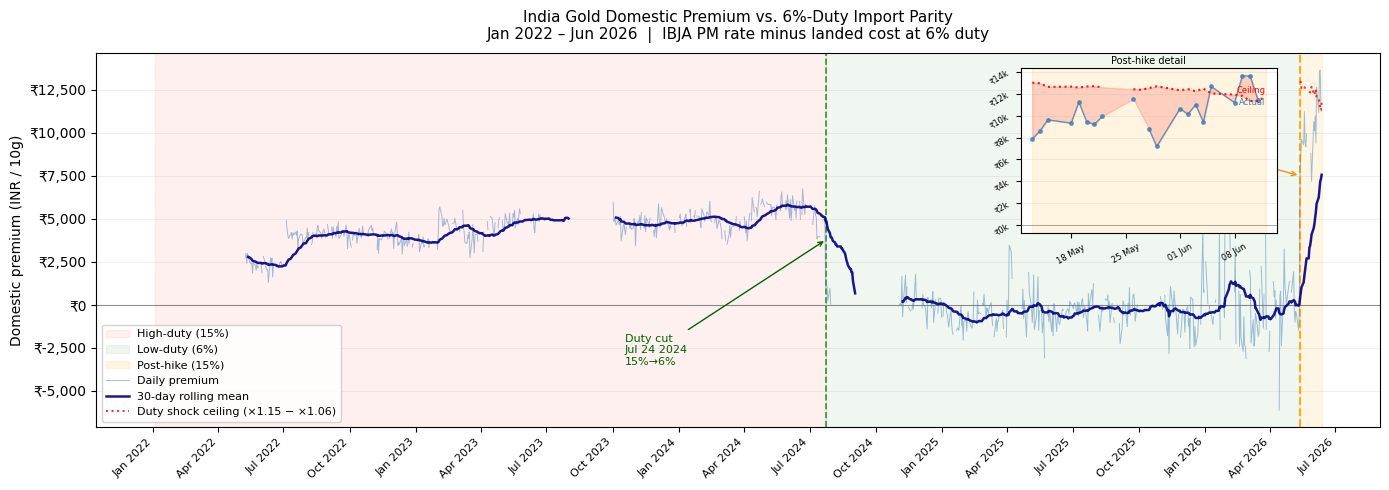

Saved → figures/fig01_premium_timeseries.png


In [9]:
# ── Cell 3: Figure 1 — domestic_premium time series (FIXED) ──────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

# ── Regime shading ────────────────────────────────────────────────────────
ax.axvspan(df.index.min(), DUTY_CUT,      alpha=0.06, color='red',    label='High-duty (15%)')
ax.axvspan(DUTY_CUT,       POLICY_DATE,   alpha=0.06, color='green',  label='Low-duty (6%)')
ax.axvspan(POLICY_DATE,    df.index.max(), alpha=0.10, color='orange', label='Post-hike (15%)')

# ── Regime boundary lines ─────────────────────────────────────────────────
ax.axvline(DUTY_CUT,    color='green',  lw=1.2, ls='--', alpha=0.8)
ax.axvline(POLICY_DATE, color='orange', lw=1.5, ls='--', alpha=0.9)

# ── Zero reference ────────────────────────────────────────────────────────
ax.axhline(0, color='black', lw=0.8, ls='-', alpha=0.4)

# ── Daily premium ─────────────────────────────────────────────────────────
ax.plot(df.index, df['domestic_premium'],
        color='steelblue', lw=0.7, alpha=0.5, label='Daily premium')

# ── 30-day rolling mean ───────────────────────────────────────────────────
roll = df['domestic_premium'].rolling(30, min_periods=5).mean()
ax.plot(df.index, roll,
        color='navy', lw=1.8, alpha=0.9, label='30-day rolling mean')

# ── Theoretical ceiling (post-hike only) ─────────────────────────────────
ceiling = (df.loc[df.index >= POLICY_DATE, 'parity_post'] -
           df.loc[df.index >= POLICY_DATE, 'parity_pre'])
ax.plot(ceiling.index, ceiling,
        color='red', lw=1.5, ls=':', alpha=0.8, label='Duty shock ceiling (×1.15 − ×1.06)')

# ── Annotations (hardcoded y to avoid pre-render ylim bug) ───────────────
ax.annotate('Duty cut\nJul 24 2024\n15%→6%',
            xy=(DUTY_CUT, 3800),
            xytext=(DUTY_CUT - pd.DateOffset(days=280), -3500),
            fontsize=8, color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.0))

ax.annotate('Duty hike\nMay 13 2026\n6%→15%',
            xy=(POLICY_DATE, 7500),
            xytext=(POLICY_DATE - pd.DateOffset(days=320), 9800),
            fontsize=8, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0))

# ── Inset: post-hike zoom ─────────────────────────────────────────────────
axins = ax.inset_axes([0.72, 0.52, 0.20, 0.44])  # shifted left to avoid annotation overlap

post = df[df.index >= POLICY_DATE].copy()
axins.axhline(0, color='black', lw=0.5, alpha=0.4)
axins.axvspan(post.index.min(), post.index.max(), alpha=0.12, color='orange')
axins.plot(post.index, post['domestic_premium'],
           color='steelblue', lw=1.0, alpha=0.8, marker='o', ms=2.5)
axins.plot(ceiling.index, ceiling.values,
           color='red', lw=1.5, ls=':', alpha=0.9)
prem_filled  = post['domestic_premium']
ceil_aligned = ceiling.reindex(post.index).ffill()
mask = prem_filled.notna() & ceil_aligned.notna()
axins.fill_between(post.index[mask],
                   prem_filled[mask],
                   ceil_aligned[mask],
                   alpha=0.15, color='red', label='Pass-through gap')
axins.set_title('Post-hike detail', fontsize=7, pad=3)
axins.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
axins.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axins.tick_params(labelsize=6, rotation=30)
axins.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
axins.tick_params(axis='y', labelsize=6)
axins.grid(axis='y', alpha=0.3, lw=0.5)

# Label ceiling and premium in inset
axins.text(ceiling.index[-1], ceiling.iloc[-1] + 300,
           'Ceiling', fontsize=6, color='red', ha='right')
axins.text(post.index[-1], post['domestic_premium'].dropna().iloc[-1] - 500,
           'Actual', fontsize=6, color='steelblue', ha='right')

# ── Main axes formatting ──────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_title('India Gold Domestic Premium vs. 6%-Duty Import Parity\n'
             'Jan 2022 – Jun 2026  |  IBJA PM rate minus landed cost at 6% duty',
             fontsize=11, pad=10)
ax.legend(loc='lower left', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_premium_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig01_premium_timeseries.png')

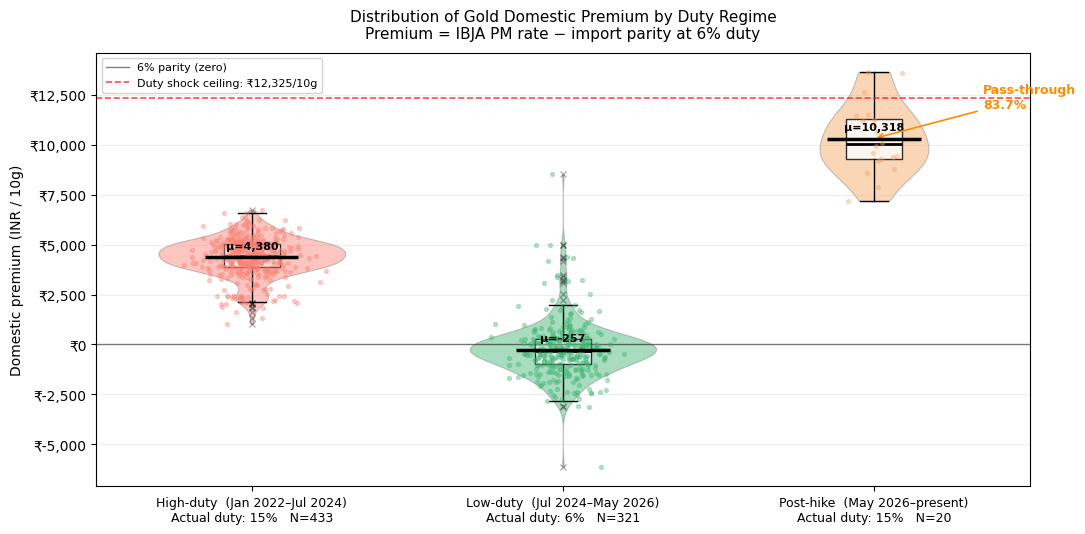

Saved → figures/fig02_premium_distribution.png


In [11]:
# ── Cell 4: Figure 2 — premium distribution by duty regime ───────────────
# Violin + strip plot showing domestic_premium distribution in each period.
# Post-hike has only N=20 — violin is unreliable there, so we show
# individual points instead and use a box plot for all three.
# This figure motivates ITS: distributions are clearly separated.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data slices ───────────────────────────────────────────────────────────
# Compute Ns from actual data (not hardcoded)
n1 = df[df.index < DUTY_CUT]['domestic_premium'].dropna().shape[0]
n2 = df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]['domestic_premium'].dropna().shape[0]
n3 = df[df.index >= POLICY_DATE]['domestic_premium'].dropna().shape[0]

slices = {
    f'High-duty  (Jan 2022–Jul 2024)\nActual duty: 15%   N={n1}':
        (df[df.index < DUTY_CUT]['domestic_premium'].dropna(), 'salmon'),
    f'Low-duty  (Jul 2024–May 2026)\nActual duty: 6%   N={n2}':
        (df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]['domestic_premium'].dropna(), 'mediumseagreen'),
    f'Post-hike  (May 2026–present)\nActual duty: 15%   N={n3}':
        (df[df.index >= POLICY_DATE]['domestic_premium'].dropna(), 'sandybrown'),
}

labels = list(slices.keys())
data   = [v[0] for v in slices.values()]
colors = [v[1] for v in slices.values()]

fig, ax = plt.subplots(figsize=(11, 6))

# ── Violin plots (all three, but narrow for post-hike) ───────────────────
vp = ax.violinplot(data, positions=[1, 2, 3],
                   widths=[0.6, 0.6, 0.35],
                   showmedians=False, showextrema=False)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color)
    body.set_alpha(0.45)
    body.set_edgecolor('grey')
    body.set_linewidth(0.8)

# ── Box plots overlaid ────────────────────────────────────────────────────
bp = ax.boxplot(data, positions=[1, 2, 3],
                widths=[0.18, 0.18, 0.18],
                patch_artist=True,
                medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor='white', alpha=0.8),
                whiskerprops=dict(lw=1.0),
                capprops=dict(lw=1.0),
                flierprops=dict(marker='x', ms=4, alpha=0.3))

# ── Individual points (jittered) — especially important for post-hike ────
for i, (series, color) in enumerate(zip(data, colors)):
    x = np.random.normal(i + 1, 0.07, size=len(series))
    ax.scatter(x, series, alpha=0.35, s=8, color=color, zorder=3)

# ── Reference lines ───────────────────────────────────────────────────────
# Zero (6% parity)
ax.axhline(0, color='black', lw=1.0, ls='-', alpha=0.5, label='6% parity (zero)')

# Theoretical duty shock ceiling (mean over post-hike window)
ceiling_mean = (df.loc[df.index >= POLICY_DATE, 'parity_post'] -
                df.loc[df.index >= POLICY_DATE, 'parity_pre']).mean()
ax.axhline(ceiling_mean, color='red', lw=1.2, ls='--', alpha=0.7,
           label=f'Duty shock ceiling: ₹{ceiling_mean:,.0f}/10g')

# Mean markers per period
for i, series in enumerate(data):
    ax.hlines(series.mean(), i + 0.85, i + 1.15,
              colors='black', lw=2.5, zorder=5)
    ax.text(i + 1, series.mean() + 300, f'μ={series.mean():,.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Pass-through annotation on post-hike panel ───────────────────────────
pt = data[2].mean() / ceiling_mean
ax.annotate(f'Pass-through\n{pt:.1%}',
            xy=(3, data[2].mean()),
            xytext=(3.35, data[2].mean() + 1500),
            fontsize=9, color='darkorange', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2))

# ── Axes formatting ───────────────────────────────────────────────────────
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_title('Distribution of Gold Domestic Premium by Duty Regime\n'
             'Premium = IBJA PM rate − import parity at 6% duty',
             fontsize=11, pad=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(FIG_DIR / 'fig02_premium_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig02_premium_distribution.png')

In [12]:
# ── Cell 5: Post-hike day-by-day event study ─────────────────────────────
# For each trading day since May 13 2026, shows:
#   - IBJA PM rate (actual domestic price)
#   - Parity at 6% (counterfactual — what price would be without hike)
#   - Parity at 15% (theoretical ceiling — 100% pass-through)
#   - domestic_premium (how far above the 6% baseline)
#   - ceiling (mechanical duty shock = parity_post − parity_pre)
#   - pass_through_pct (premium / ceiling × 100)
#
# This is the event study table for the paper's results section.
# It also reveals whether pass-through is converging or plateauing.

import pandas as pd

post = df[df.index >= POLICY_DATE].copy()

post['ceiling']          = post['parity_post'] - post['parity_pre']
post['pass_through_pct'] = (post['domestic_premium'] / post['ceiling']) * 100
post['day']              = range(1, len(post) + 1)

cols = ['day', 'Gold_INR_PM', 'parity_pre', 'parity_post',
        'domestic_premium', 'ceiling', 'pass_through_pct']

display_tbl = post[cols].copy()
display_tbl.index = display_tbl.index.strftime('%Y-%m-%d')
display_tbl.index.name = 'Date'

# ── Format for readability ────────────────────────────────────────────────
fmt = {
    'day':              '{:.0f}',
    'Gold_INR_PM':      '₹{:,.0f}',
    'parity_pre':       '₹{:,.0f}',
    'parity_post':      '₹{:,.0f}',
    'domestic_premium': '₹{:,.0f}',
    'ceiling':          '₹{:,.0f}',
    'pass_through_pct': '{:.1f}%',
}

display_tbl.columns = ['Day', 'IBJA PM (₹/10g)', 'Parity 6%',
                        'Parity 15%', 'Premium', 'Ceiling', 'Pass-through %']

pd.set_option('display.float_format', '{:,.1f}'.format)
print('=== Post-hike event study (May 13 2026 onward) ===\n')
print(display_tbl.to_string())

# ── Summary stats ─────────────────────────────────────────────────────────
pt = post['pass_through_pct'].dropna()
print(f'\n--- Pass-through summary ---')
print(f'  Day 1  (May 13): {post["pass_through_pct"].iloc[0]:.1f}%')
print(f'  Week 1 mean    : {pt.iloc[:5].mean():.1f}%')
print(f'  Week 2 mean    : {pt.iloc[5:10].mean():.1f}%  (if available)')
print(f'  Week 3 mean    : {pt.iloc[10:15].mean():.1f}%  (if available)')
print(f'  Week 4 mean    : {pt.iloc[15:20].mean():.1f}%  (if available)')
print(f'  Overall mean   : {pt.mean():.1f}%')
print(f'  Trend (Day1→last): {pt.iloc[0]:.1f}% → {pt.dropna().iloc[-1]:.1f}%')
print(f'\n  Ceiling mean (₹): {post["ceiling"].mean():,.0f}')
print(f'  Premium mean (₹): {post["domestic_premium"].mean():,.0f}')

=== Post-hike event study (May 13 2026 onward) ===

            Day  IBJA PM (₹/10g)  Parity 6%  Parity 15%  Premium  Ceiling  Pass-through %
Date                                                                                     
2026-05-13    1        160,977.0  153,105.1   166,104.6  7,871.9 12,999.5            60.6
2026-05-14    2        161,159.0  152,566.4   165,520.2  8,592.6 12,953.8            66.3
2026-05-15    3        158,210.0  148,599.8   161,216.7  9,610.2 12,617.0            76.2
2026-05-18    4        158,210.0  148,896.1   161,538.3  9,313.9 12,642.1            73.7
2026-05-19    5        159,077.0  147,845.7   160,398.6 11,231.3 12,552.9            89.5
2026-05-20    6        158,555.0  149,122.4   161,783.7  9,432.6 12,661.3            74.5
2026-05-21    7        158,538.0  149,344.1   162,024.2  9,193.9 12,680.2            72.5
2026-05-22    8        158,117.0  148,179.6   160,760.9  9,937.4 12,581.3            79.0
2026-05-25    9        158,857.0        NaN     